In [2]:
import subprocess
import os
import sys
import matplotlib.pyplot as plt
import pandas
import numpy as np
import subprocess

In [3]:
commande = ["make", "run", 'ARGS=net3_1s.inp output_epanet.txt output_algo.txt 0.5 1.0']
resultat = subprocess.run(commande, capture_output=True, text=True)

print(resultat.stdout)
print(resultat.stderr)

gcc -O3 -Wall -Ilibrairie/EPANET_2_3_5_LINUX_x86_64 -o epanet_exec src/structure.c src/algorithm_flow.c src/epanet_parser.c src/main.c -Llibrairie/EPANET_2_3_5_LINUX_x86_64 -lepanet2 -lm -Wl,-rpath=librairie/EPANET_2_3_5_LINUX_x86_64
./epanet_exec net3_1s.inp output_epanet.txt output_algo.txt 0.5 1.0




In [4]:
def parser(path):
    with open(path, 'r') as f:
        n = int(f.readline().strip())
        arcs = int(f.readline().strip())
        return  (arcs, n, np.loadtxt(f).reshape(n, n))

parser('output_epanet.txt')

(214,
 87,
 array([[    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        ...,
        [    0.    ,     0.    ,     0.    , ...,     0.    ,   437.6261,
             0.    ],
        [    0.    ,     0.    ,     0.    , ...,     0.    ,     0.    ,
             0.    ],
        [    0.    ,     0.    , 40751.4816, ...,     0.    ,     0.    ,
             0.    ]], shape=(87, 87)))

In [5]:
def hamming_distance_non_symmetrique(m1, m2):
    return np.sum((m1 != 0) != (m2 != 0))

def hamming_distance_symmetrique(m1, m2):
    mask = np.triu(np.ones(m1.shape, dtype=bool), k=1)
    return np.sum(((m1 != 0) != (m2 != 0))[mask])

arcs, n, result= parser('output_epanet.txt')
print(result.shape)
print("EPANET comparaison:\n" + "nbr arcs=" + str(arcs) + "\n" + "nbr noeuds=" + str(n))
arcs, n, result_algo = parser('output_algo.txt')

print(hamming_distance_non_symmetrique(result, result_algo))
print(hamming_distance_symmetrique(result, result_algo))

(87, 87)
EPANET comparaison:
nbr arcs=214
nbr noeuds=87
107
65


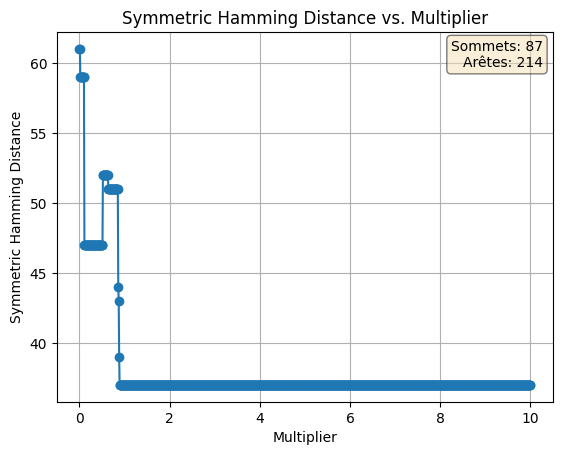

In [28]:
multipliers = np.linspace(0.0001, 10.0, 1000)
distances = []

for mult in multipliers:
	commande = ["make", "run", f'ARGS=net3_1s.inp output_epanet.txt output_algo.txt {mult} 1.0']
	resultat = subprocess.run(commande, capture_output=True, text=True)

	arcs, n, result = parser('output_epanet.txt')
	arcs, n, result_algo = parser('output_algo.txt')

	dist = hamming_distance_symmetrique(result, result_algo)
	distances.append(dist)

fig, ax = plt.subplots()
ax.plot(multipliers, distances, marker='o')
ax.set_xlabel('Multiplier')
ax.set_ylabel('Symmetric Hamming Distance')
ax.set_title('Symmetric Hamming Distance vs. Multiplier')
ax.grid(True)

# Add number of nodes and arcs at top right
ax.text(0.98, 0.98, f'Sommets: {n}\nArêtes: {arcs}', 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()